In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
dataset=pd.read_csv("NYC.csv")
dataset=dataset.drop("id" ,axis=1)

In [88]:
dataset.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [89]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   pickup_datetime     1458644 non-null  object 
 2   dropoff_datetime    1458644 non-null  object 
 3   passenger_count     1458644 non-null  int64  
 4   pickup_longitude    1458644 non-null  float64
 5   pickup_latitude     1458644 non-null  float64
 6   dropoff_longitude   1458644 non-null  float64
 7   dropoff_latitude    1458644 non-null  float64
 8   store_and_fwd_flag  1458644 non-null  object 
 9   trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 111.3+ MB


In [90]:
dataset.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [91]:
print(dataset.isnull().sum()) 

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [92]:
print(dataset.columns[dataset.columns == ""])

Index([], dtype='object')


In [93]:
(dataset == "").sum()

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [94]:
(dataset == " ").sum()

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

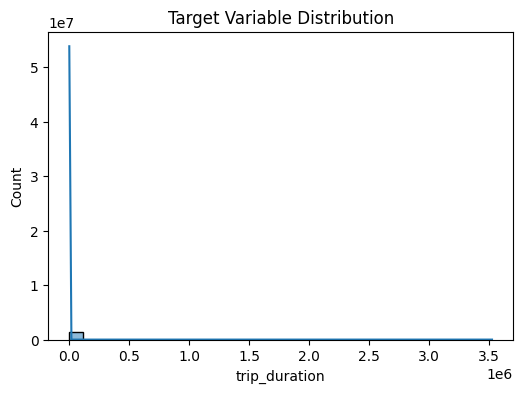

In [95]:
plt.figure(figsize=(6,4))
sns.histplot(dataset['trip_duration'], kde=True,bins=30)
plt.title('Target Variable Distribution')
plt.show()

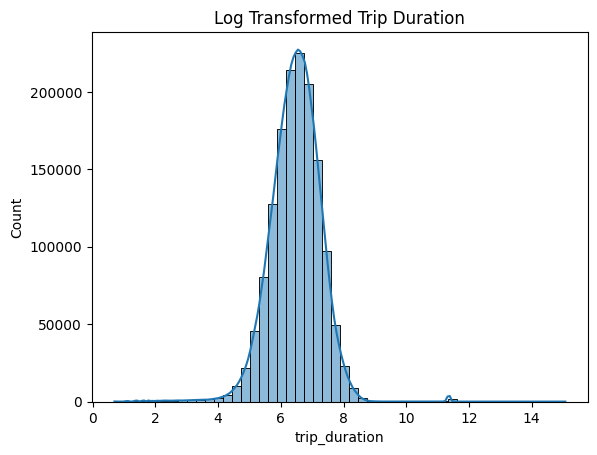

In [96]:
sns.histplot(np.log1p(dataset['trip_duration']), bins=50, kde=True)
plt.title("Log Transformed Trip Duration")
plt.show()

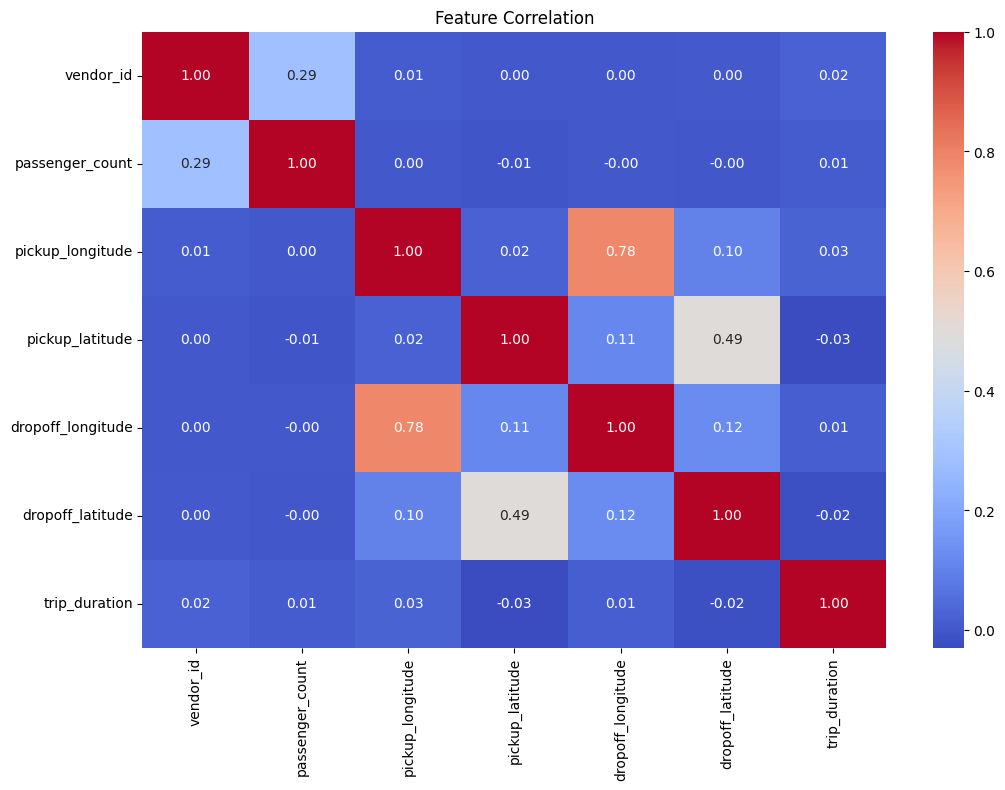

In [97]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [98]:
cat_cols=dataset.select_dtypes(exclude=np.number).columns
cat_cols=list(cat_cols)
print(cat_cols)

['pickup_datetime', 'dropoff_datetime', 'store_and_fwd_flag']


In [99]:
def preprocess(dataset):
    dataset= dataset.copy()
    # datetime
    dataset['pickup_datetime'] = pd.to_datetime(dataset['pickup_datetime'])
    dataset['dropoff_datetime'] = pd.to_datetime(dataset['dropoff_datetime'])
    
    dataset['pickup_hour'] = dataset['pickup_datetime'].dt.hour
    dataset['pickup_minutes'] = dataset['pickup_datetime'].dt.minute

    dataset['dropoff_hour'] = dataset['dropoff_datetime'].dt.hour
    dataset['dropoff_minutes'] = dataset['dropoff_datetime'].dt.minute
    
    dataset['day_of_week'] = dataset['pickup_datetime'].dt.dayofweek
    dataset['is_weekend'] = dataset['day_of_week'].apply(lambda x: 1 if x > 5 else 0)
    dataset['is_rush_hour'] = dataset['pickup_hour'].isin([7,8,9,10,16,17,18,19,20]).astype(int)
   
    # haversine
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371  # Earth radius in km
        
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        
        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        
        return R * c

    def manhattan(lat1, lon1, lat2, lon2):
        return (
            haversine(lat1, lon1, lat2, lon1) +
            haversine(lat2, lon1, lat2, lon2)
        )
    # Bearing (Direction)
    def bearing(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        
        dlon = lon2 - lon1
        
        x = np.sin(dlon) * np.cos(lat2)
        y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
        
        
        angle = np.degrees(np.arctan2(x, y))
        return (angle + 360) % 360

    dataset['haversine_km'] = haversine(
        dataset['pickup_latitude'], dataset['pickup_longitude'],
        dataset['dropoff_latitude'], dataset['dropoff_longitude']
    )
    
    dataset['manhattan_km'] = manhattan(
        dataset['pickup_latitude'], dataset['pickup_longitude'],
        dataset['dropoff_latitude'], dataset['dropoff_longitude']
    )
    
    dataset['bearing'] = bearing(
        dataset['pickup_latitude'], dataset['pickup_longitude'],
        dataset['dropoff_latitude'], dataset['dropoff_longitude']
    )
    # flag encoding
    dataset['store_and_fwd_flag'] = (
    dataset['store_and_fwd_flag']
    .astype(str)          # ensure string
    .str.strip()          # remove spaces
    .str.lower()          # convert to lowercase
    .map({'y':1, 'n':0})  # mapping
    .fillna(0)            # handle unknown
    )
    dataset.drop([
    'pickup_latitude',
    'pickup_longitude',
    'dropoff_latitude',
    'dropoff_longitude',
    'pickup_datetime',
    'dropoff_datetime'
    ], axis=1, inplace=True)
       
    return dataset


In [100]:
dataset = preprocess(dataset)

In [101]:
# dataset = dataset.sample(100000, random_state=42)

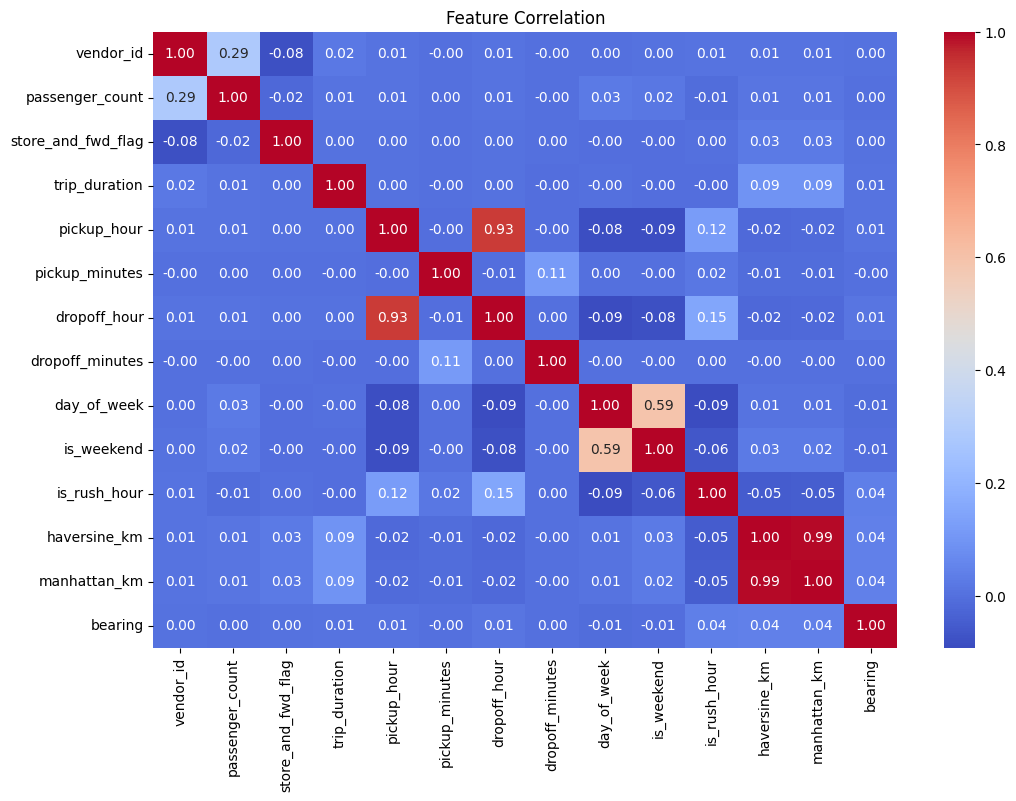

In [102]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

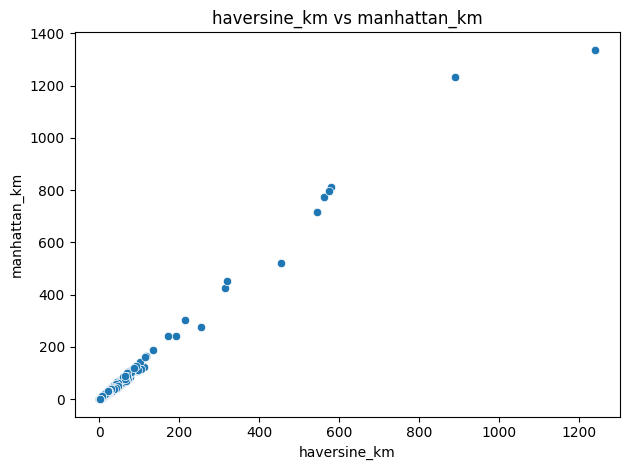

In [103]:
sns.scatterplot(x='haversine_km', y='manhattan_km', data=dataset)
plt.title('haversine_km vs manhattan_km')
plt.tight_layout()
plt.show()

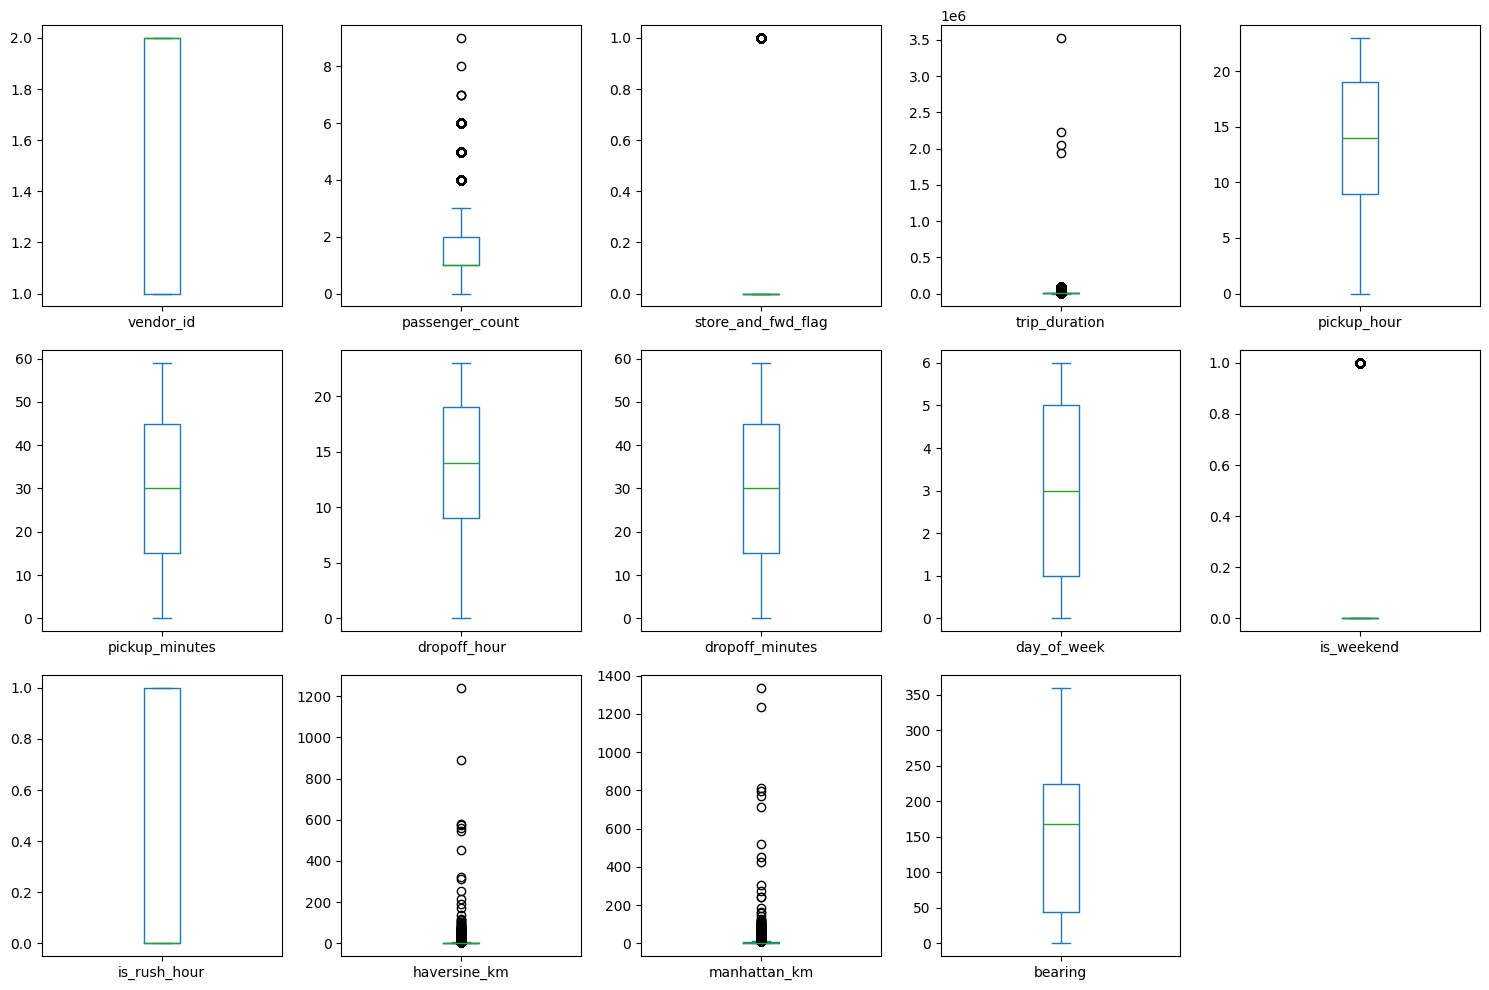

In [104]:
dataset.select_dtypes(include='number').plot(
    kind='box', 
    subplots=True, 
    figsize=(15,10),
    layout=(3,5))
plt.tight_layout()
plt.show()

In [105]:
print(dataset.head())

   vendor_id  passenger_count  store_and_fwd_flag  trip_duration  pickup_hour  \
0          2                1                   0            455           17   
1          1                1                   0            663            0   
2          2                1                   0           2124           11   
3          2                1                   0            429           19   
4          2                1                   0            435           13   

   pickup_minutes  dropoff_hour  dropoff_minutes  day_of_week  is_weekend  \
0              24            17               32            0           0   
1              43             0               54            6           1   
2              35            12               10            1           0   
3              32            19               39            2           0   
4              30            13               38            5           0   

   is_rush_hour  haversine_km  manhattan_km     be

In [106]:
print(dataset.shape)

(1458644, 14)


In [107]:
q_low = dataset['trip_duration'].quantile(0.01)
q_high = dataset['trip_duration'].quantile(0.99)

dataset = dataset[(dataset['trip_duration'] >= q_low) & (dataset['trip_duration'] <= q_high)]
#noise removal
dataset = dataset[(dataset['trip_duration'] > 60) & (dataset['trip_duration'] < 14400)]

dataset['trip_duration'] = np.log1p(dataset['trip_duration'])


In [108]:
print(dataset.shape)

(1429538, 14)


In [109]:
Q1 = dataset['haversine_km'].quantile(0.25)
Q3 = dataset['haversine_km'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

dataset = dataset[(dataset['haversine_km'] >= lower_bound) & 
        (dataset['haversine_km'] <= upper_bound)]


In [110]:
print(dataset.shape)

(1297235, 14)


In [111]:
Q1 = dataset['manhattan_km'].quantile(0.25)
Q3 = dataset['manhattan_km'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

dataset = dataset[(dataset['manhattan_km'] >= lower_bound) & 
        (dataset['manhattan_km'] <= upper_bound)]

In [112]:
print(dataset.shape)

(1241228, 14)


In [113]:
def fare_estimate(dataset, pred_duration):
    base_fare = 2.5
    
    distance = dataset['haversine_km'].iloc[0]
    time = pred_duration / 60  
    rush = dataset['is_rush_hour'].iloc[0]
    passenger_count = dataset['passenger_count'].iloc[0]
    hour = dataset['pickup_hour'].iloc[0]
    
    # Core fare
    fare = base_fare + (distance * 1.5) + (time * 0.5)
    
    # Rush hour surge
    if rush == 1:
        fare *= 1.2
    
    # Night surcharge (8 PM – 6 AM)
    if hour >= 20 or hour <= 6:
        fare += 1.0
    
    #  Passenger surcharge
    fare += passenger_count * 0.5
    
    # Minimum fare constraint
    fare = max(fare, 3.0)
    
    return round(fare, 2)

In [114]:
print(dataset.columns)

Index(['vendor_id', 'passenger_count', 'store_and_fwd_flag', 'trip_duration',
       'pickup_hour', 'pickup_minutes', 'dropoff_hour', 'dropoff_minutes',
       'day_of_week', 'is_weekend', 'is_rush_hour', 'haversine_km',
       'manhattan_km', 'bearing'],
      dtype='object')


In [115]:
print(dataset.shape)

(1241228, 14)


In [116]:
x = dataset.drop('trip_duration', axis=1)
y = dataset['trip_duration']

In [117]:
from sklearn.model_selection import train_test_split
x_train ,x_test ,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0  )

In [118]:
print(x_train.head())

         vendor_id  passenger_count  store_and_fwd_flag  pickup_hour  \
900425           2                1                   0           18   
1271243          2                1                   0            1   
1091465          1                2                   0           15   
880448           2                1                   0           19   
927838           2                2                   0            8   

         pickup_minutes  dropoff_hour  dropoff_minutes  day_of_week  \
900425               38            18               43            0   
1271243              59             2               15            0   
1091465               8            15               28            3   
880448               16            19               26            0   
927838               48             9               12            0   

         is_weekend  is_rush_hour  haversine_km  manhattan_km     bearing  
900425            0             1      1.130658      1.399838   

In [119]:
x_train.shape

(992982, 13)

In [120]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
sc_y=StandardScaler()
x_train = pd.DataFrame(sc_x.fit_transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame( sc_x.transform(x_test), columns=x_test.columns)
y_train = pd.DataFrame(sc_y.fit_transform(y_train.values.reshape(-1, 1)), 
                       columns=['trip_duration'])
features=x_train.columns

In [121]:
x_train.shape

(992982, 13)

In [122]:
x_train= x_train.to_numpy()
x_test= x_test.to_numpy()
y_train= y_train.to_numpy()
y_test= y_test.to_numpy()
y_train = y_train.ravel() 

In [123]:
# from sklearn.linear_model import LinearRegression
# from sklearn.preprocessing import PolynomialFeatures
# poly = PolynomialFeatures(degree=2)
# x_train = poly.fit_transform(x_train)
# x_test = poly.transform(x_test)

# model = LinearRegression()
from xgboost import XGBRegressor
model=XGBRegressor()
model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [124]:
y_pred = sc_y.inverse_transform(model.predict(x_test).reshape(-1,1))

np.set_printoptions(precision=2)
print(np.concatenate((y_pred, y_test.reshape(len(y_test),1)), 1))

[[6.52 6.46]
 [6.79 6.74]
 [7.19 7.13]
 ...
 [6.63 6.69]
 [6.3  6.34]
 [7.1  7.13]]


In [125]:
x_train.shape

(992982, 13)

In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2 Score : {r2:.2f}")

MAE  : 0.08
MSE  : 0.01
RMSE : 0.11
R2 Score : 0.97


In [127]:
from sklearn.model_selection import cross_val_score

R2 = cross_val_score(estimator=model, X=x_train, y=y_train.ravel(), cv=10, scoring='r2')

print("R2 Score: {:.2f} %".format(R2.mean()*100))
print("Standard Deviation: {:.2f} %".format(R2.std()*100))

R2 Score: 97.15 %
Standard Deviation: 0.12 %


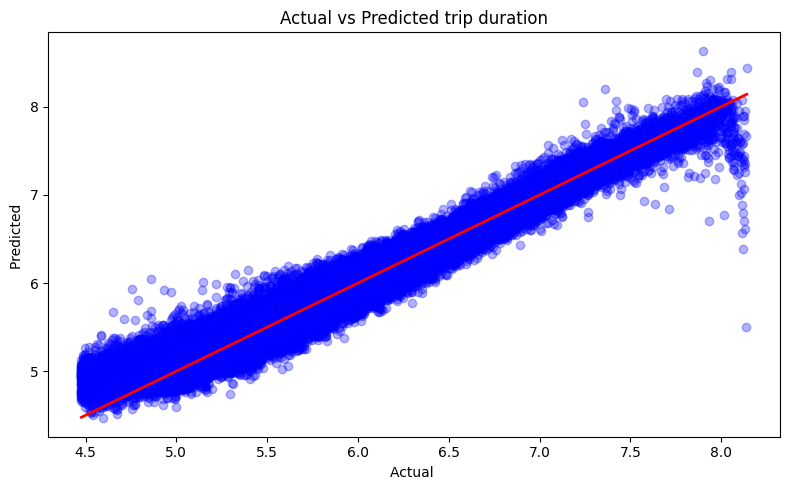

In [128]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2)
plt.title('Actual vs Predicted trip duration')
plt.xlabel('Actual ')
plt.ylabel('Predicted ')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50,random_state=0),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=0)
    "XGB":XGBRegressor()
}

poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train.ravel())

y_pred_poly = sc_y.inverse_transform(poly_model.predict(x_test_poly).reshape(-1,1))

r2_poly = r2_score(y_test, y_pred_poly)

results = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = sc_y.inverse_transform(model.predict(x_test).reshape(-1,1))
    r2= r2_score(y_test, y_pred)
    results[name] = round(r2* 100, 2)
    print(f"{name}: {r2*100:.2f}%")
results["Polynomial Regression"]=round(r2_poly* 100, 2)
print(f"Polynomial Regression: {r2_poly*100:.2f}%")

In [ ]:
plt.figure(figsize=(8,5))
colors = ['blue', 'green', 'orange', 'red', 'purple']
plt.bar(results.keys(), results.values(), color=colors)
plt.title('Model Comparison - trip duration Prediction')
plt.xlabel('Models')
plt.ylabel('R2 Score(%)')
plt.ylim([10, 100])
plt.xticks(rotation=15)
for i, (model, r2) in enumerate(results.items()):
    plt.text(i, r2 + 0.1, f"{r2}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [129]:
new_data = pd.DataFrame([{
    'vendor_id':1,            
    'pickup_datetime':'2016-06-12 00:43:35',     
    'dropoff_datetime':'2016-06-12 00:54:38',
    'passenger_count':1,   
    'pickup_longitude':-73.980415344238281 ,
    'pickup_latitude':40.738563537597656 ,  
    'dropoff_longitude':-73.999481201171875 ,   
    'dropoff_latitude':40.731151580810547 ,   
    'store_and_fwd_flag':'N'
}])


new_data = preprocess(new_data)
new_data = new_data.reindex(columns=features, fill_value=0)
new_data_scaled = sc_x.transform(new_data)
pred_duration_log= sc_y.inverse_transform(model.predict(new_data_scaled).reshape(-1,1))
pred_duration=np.expm1(pred_duration_log)
print("Predicted trip duration (sec):", round((pred_duration[0][0]), 2))
print("Predicted trip duration (min):", round((pred_duration[0][0]/60), 2))
fare = fare_estimate(new_data, pred_duration.item())
print("Estimated Fare ($):", round(fare, 2))
print("Estimated distance (km):", round(new_data['haversine_km'].iloc[0], 2))
distance = new_data['haversine_km'].iloc[0]
time_hr = pred_duration[0] / 3600

speed = distance / time_hr

print("Estimated speed (km/h):", round(speed.item(), 2))

Predicted trip duration (sec): 695.82
Predicted trip duration (min): 11.6
Estimated Fare ($): 12.51
Estimated distance (km): 1.81
Estimated speed (km/h): 9.34
